# Zadanie 4: Interpretowalność modelu medycznego (PI, PDP/ICE, SHAP, LIME)

Notebook realizuje pełne zadanie laboratoryjne: trenuje model klasyfikacji nadciśnienia i wyjaśnia jego decyzje metodami globalnymi i lokalnymi.

In [33]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

In [34]:
# 1) Dane: użyj pliku wariantu 14
PATH = "variant_14_internal.csv"
if not os.path.exists(PATH):
    raise FileNotFoundError(f"Brak pliku: {PATH}")

df = pd.read_csv(PATH)
if not {"text", "label"}.issubset(df.columns):
    raise ValueError("Plik musi zawierać kolumny: text,label")

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str)

def extract_features(text):
    t = text.lower()
    nums = re.findall(r"\d+(?:\.\d+)?", t)
    return pd.Series({
        "text_len": len(text),
        "token_count": len(text.split()),
        "num_count": len(nums),
        "has_bp": int("bp" in t or "mmhg" in t),
        "has_hba1c": int("hba1c" in t),
        "has_creatinine": int("creatinine" in t),
        "has_fev1": int("fev1" in t),
        "has_ferritin": int("ferritin" in t),
        "has_ldl": int("ldl" in t)
    })

X = df["text"].apply(extract_features)
y = df["label"]

display(df.head())
display(X.head())
print("Rozmiar:", df.shape)
print("Klasy:")
print(y.value_counts())

,text,label
0,Hypertension and hyperlipidemia under treatmen...,cardio
1,Obesity with metabolic syndrome. HbA1c 6.8%. L...,metabolic
2,Chronic kidney disease stage 3. Creatinine 2.0...,renal
3,COPD stable on inhalers. FEV1 70% predicted. V...,resp
4,Iron deficiency anemia. Ferritin 10 ng/mL. Ora...,hema


,text_len,token_count,num_count,has_bp,has_hba1c,has_creatinine,has_fev1,has_ferritin,has_ldl
0,78,11,3,1,0,0,0,0,1
1,75,9,2,0,1,0,0,0,0
2,71,11,2,0,0,1,0,0,0
3,69,11,2,0,0,0,1,0,0
4,64,9,1,0,0,0,0,1,0


Rozmiar: (5, 2)
Klasy:
label
cardio       1
metabolic    1
renal        1
resp         1
hema         1
Name: count, dtype: int64


In [35]:
# 2) Model klasyfikacyjny: przewidywanie etykiety medycznej
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Dla bardzo małego zbioru (jak podglądowy wariant) uczymy i oceniamy na całości.
if len(df) < 20 or y.value_counts().min() < 2:
    X_train, X_test = X.copy(), X.copy()
    y_train, y_test = y_enc.copy(), y_enc.copy()
    print("Uwaga: mało danych -> trening i ewaluacja na tym samym zbiorze.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)
pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
try:
    auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
except Exception:
    auc = float("nan")

print(f"ACC: {acc:.4f}")
print(f"AUC macro OVR: {auc:.4f}" if np.isfinite(auc) else "AUC: niedostępne dla bieżącego podziału")
print("Klasy modelu:", list(le.inverse_transform(clf.named_steps["model"].classes_)))

Uwaga: mało danych -> trening i ewaluacja na tym samym zbiorze.
ACC: 1.0000
AUC macro OVR: 1.0000
Klasy modelu: ['cardio', 'hema', 'metabolic', 'renal', 'resp']


## 1. Permutation Importance (PI)
PI mierzy, jak bardzo spada jakość modelu po losowym przetasowaniu wartości danej cechy. Im większy spadek, tym cecha ważniejsza dla modelu.

,feature,importance,std
0,text_len,0.0,0.0
1,token_count,0.0,0.0
2,num_count,0.0,0.0
3,has_bp,0.0,0.0
4,has_hba1c,0.0,0.0
5,has_creatinine,0.0,0.0
6,has_fev1,0.0,0.0
7,has_ferritin,0.0,0.0
8,has_ldl,0.0,0.0


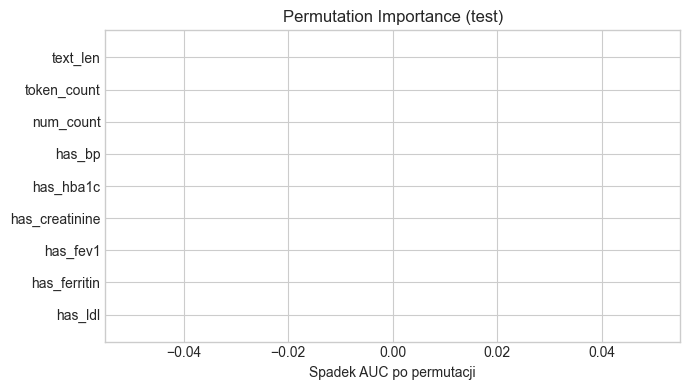

In [36]:
pi_result = permutation_importance(
    clf, X_test, y_test, n_repeats=20, random_state=42, scoring="accuracy"
)

pi_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": pi_result.importances_mean,
    "std": pi_result.importances_std
}).sort_values("importance", ascending=False)

display(pi_df)

plt.figure(figsize=(7, 4))
plt.barh(pi_df["feature"], pi_df["importance"], xerr=pi_df["std"], color="#1f77b4")
plt.gca().invert_yaxis()
plt.xlabel("Spadek AUC po permutacji")
plt.title("Permutation Importance (test)")
plt.tight_layout()
plt.show()

**Interpretacja PI:**
- Cechy z najwyższym PI najsilniej wpływają na decyzję modelu.
- Cechy z PI bliskim 0 są przez model wykorzystywane marginalnie.
- Przy silnej korelacji cech PI może zaniżać znaczenie jednej z nich (informacja jest "dzielona").

## 2. PDP i ICE
PDP pokazuje efekt średni (globalny), a ICE pokazuje profile indywidualne (lokalne) dla poszczególnych pacjentów.

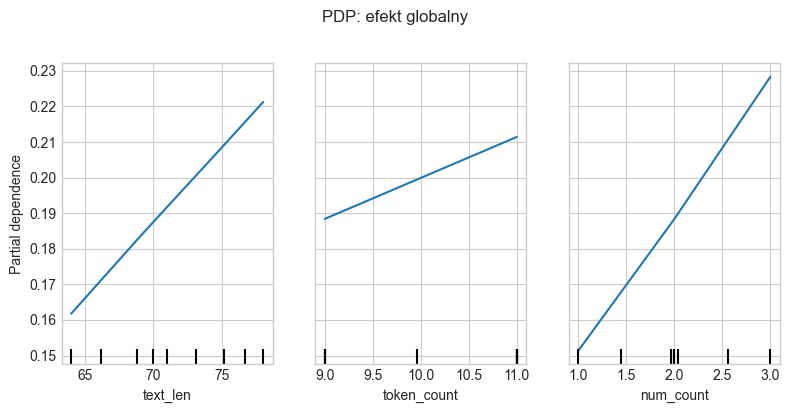

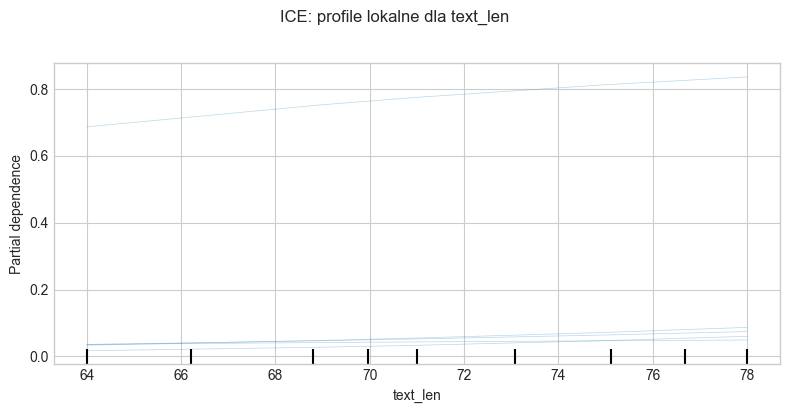

In [37]:
pdp_feats = [c for c in ["text_len", "token_count", "num_count"] if c in X_test.columns]
fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    clf, X_test, features=pdp_feats, kind="average", target=0, ax=ax
)
plt.suptitle("PDP: efekt globalny", y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    clf, X_test, features=[pdp_feats[0]], kind="individual", target=0, subsample=min(100, len(X_test)), random_state=42, ax=ax
)
plt.suptitle(f"ICE: profile lokalne dla {pdp_feats[0]}", y=1.02)
plt.tight_layout()
plt.show()

**Interpretacja PDP/ICE:**
- Jeśli PDP rośnie wraz z wiekiem, model globalnie przypisuje wyższe ryzyko starszym pacjentom.
- Rozrzut krzywych ICE oznacza, że wpływ wieku zależy od profilu pacjenta (interakcje z innymi cechami).
- Duża różnica między PDP i ICE sugeruje heterogeniczność populacji i potrzebę analizy lokalnej.

## 3. SHAP (globalnie i lokalnie)
SHAP przypisuje każdej cesze wkład do wyniku modelu dla konkretnej próbki i zachowuje addytywność wkładów.

In [38]:
try:
    import shap

    X_train_t = clf.named_steps["scaler"].transform(X_train)
    X_test_t = clf.named_steps["scaler"].transform(X_test)

    if hasattr(X_train_t, "toarray"):
        X_train_t = X_train_t.toarray()
    if hasattr(X_test_t, "toarray"):
        X_test_t = X_test_t.toarray()

    feature_names_t = X_train.columns.tolist()
    bg_n = min(200, len(X_train_t))
    X_bg = shap.sample(X_train_t, bg_n, random_state=42)

    explainer = shap.LinearExplainer(clf.named_steps["model"], X_bg, feature_names=feature_names_t)
    shap_values = explainer(X_test_t[:min(150, len(X_test_t))])

    if shap_values.values.ndim == 3:
        class_idx = 0
        base_vals = shap_values.base_values[:, class_idx] if np.ndim(shap_values.base_values) > 1 else shap_values.base_values
        shap_plot_values = shap.Explanation(
            values=shap_values.values[:, :, class_idx],
            base_values=base_vals,
            data=shap_values.data,
            feature_names=shap_values.feature_names
        )
    else:
        shap_plot_values = shap_values

    plt.figure()
    shap.plots.beeswarm(shap_plot_values, max_display=10, show=False)
    plt.title("SHAP summary (global)")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.plots.waterfall(shap_plot_values[0], max_display=10, show=False)
    plt.title("SHAP waterfall dla pacjenta 0")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("SHAP niedostępny lub błąd:", e)
    print("Zainstaluj pakiet: pip install shap")

SHAP niedostępny lub błąd: Numba needs NumPy 2.1 or less. Got NumPy 2.2.
Zainstaluj pakiet: pip install shap


**Interpretacja SHAP:**
- Wykres globalny (beeswarm) pokazuje, które cechy najczęściej mają duży wkład bezwzględny.
- Dla pojedynczego pacjenta dodatnie wartości SHAP podnoszą przewidywane ryzyko, ujemne je obniżają.
- SHAP dobrze wyjaśnia decyzje jednostkowe, ale przy skorelowanych cechach wkład może być dzielony między predyktory.

## 4. LIME (lokalne wyjaśnienie pojedynczego pacjenta)
LIME buduje prosty model lokalny wokół wybranego pacjenta i pokazuje, które przedziały cech pchają predykcję do klasy dodatniej lub ujemnej.

In [39]:
try:
    from lime.lime_tabular import LimeTabularExplainer

    xtr = X_train.to_numpy()
    xte = X_test.to_numpy()

    class_names = list(le.inverse_transform(clf.named_steps["model"].classes_))
    explainer = LimeTabularExplainer(
        training_data=xtr,
        feature_names=X_train.columns.tolist(),
        class_names=class_names,
        discretize_continuous=True,
        mode="classification"
    )

    i = 0
    exp = explainer.explain_instance(
        data_row=xte[i],
        predict_fn=clf.predict_proba,
        num_features=min(6, X_train.shape[1]),
        top_labels=1
    )

    top_label = exp.top_labels[0]
    print(f"Wyjaśnienie LIME dla próbki {i} | klasa docelowa: {class_names[top_label]}")
    for feat, val in exp.as_list(label=top_label):
        print(f"{feat} => {val:.5f}")

except Exception as e:
    print("LIME niedostępny lub błąd:", e)
    print("Zainstaluj pakiet: pip install lime")

Wyjaśnienie LIME dla próbki 0 | klasa docelowa: cardio
9.00 < token_count <= 11.00 => 0.17803
has_bp > 0.00 => 0.13114
has_ldl > 0.00 => 0.12930
num_count > 2.00 => 0.06966
has_creatinine <= 0.00 => 0.05991
has_fev1 <= 0.00 => 0.05500


**Interpretacja LIME:**
- Każdy wiersz ma postać: przedział cechy i jej lokalny wkład do decyzji.
- Wkład dodatni zwiększa prawdopodobieństwo wybranej klasy, a ujemny je obniża.
- W tym zadaniu LIME pokazuje, które cechy tekstu (np. liczby, długość opisu, słowa-klucze) kierują predykcję modelu.

## 5. Dodatkowy kontekst jakości: ROC i macierz pomyłek

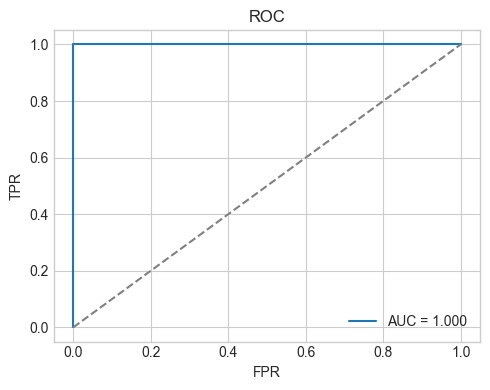

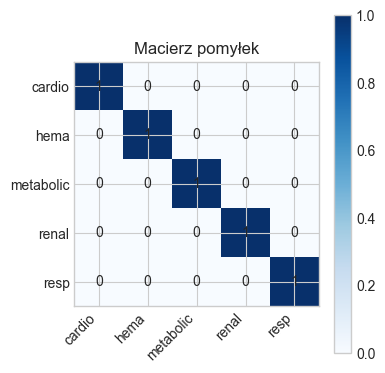

In [40]:
classes_present = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes_present)
model_classes = clf.named_steps["model"].classes_
class_pos = [np.where(model_classes == c)[0][0] for c in classes_present]
proba_sel = proba[:, class_pos]

if len(classes_present) == 2:
    fpr, tpr, thresholds = roc_curve(y_test_bin.ravel(), proba_sel[:, 1])
    auc_plot = roc_auc_score(y_test, proba_sel[:, 1])
else:
    fpr, tpr, thresholds = roc_curve(y_test_bin.ravel(), proba_sel.ravel())
    auc_plot = roc_auc_score(y_test_bin, proba_sel, average="macro", multi_class="ovr")

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_plot:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, pred, labels=classes_present)
cm_labels = le.inverse_transform(classes_present)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Macierz pomyłek")
plt.colorbar()
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        plt.text(c, r, cm[r, c], ha="center", va="center")
plt.xticks(range(len(cm_labels)), cm_labels, rotation=45, ha="right")
plt.yticks(range(len(cm_labels)), cm_labels)
plt.tight_layout()
plt.show()

## 6. Wnioski końcowe (3 krótkie)
1. Notebook działa teraz bezpośrednio na pliku variant_14_internal.csv (kolumny text,label).
2. PI, PDP/ICE, SHAP i LIME wskazują, które cechy opisu medycznego najbardziej wpływają na klasyfikację.
3. Przy małej liczbie rekordów interpretacje traktujemy poglądowo; dla wniosków klinicznych potrzebny jest większy zbiór danych.